# Lecture 3 — Continuous Opacity *(GPU Edition)*

*Stellar Spectroscopy from Scratch — GPU Edition: the torch/MPS vectorized companion, each part validated against the NumPy edition*

*Yuan-Sen Ting*

*Written in collaboration with **Claude Opus 4.8**, under the author's supervision. Schematics generated with **Gemini 3 Pro** (Nano Banana).*

*This is the **GPU edition** of Lecture 3. The physics, the formulas, and the constants are identical to the [NumPy edition](https://github.com/tingyuansen/stellar-spectroscopy-from-scratch); the continuous opacity is rebuilt in clean **`torch`** that runs on the GPU (Apple **MPS** or **CUDA**, with a CPU fallback in fp64). The crucial new axis here is **wavelength**: where Lecture 2 batched over the 80 atmospheric depths, the continuum is a function of depth **and** wavelength, so every opacity source is a single tensor expression broadcast over the full $(80 \times 200)$ grid — no Python loop over depths or wavelengths. The lecture ends with two comparison cells: one against the production reference `L3.npz` (the analytic model's honest few-percent physics fidelity), and one against the GPU's **own NumPy fp64 twin** (the fp32 float floor, which proves the vectorization is bit-correct). The notebook imports neither `kgpu` nor pykurucz.*

---

**Learning objectives.** By the end of this lecture you will be able to:

- Distinguish **true absorption** from **scattering**, and write the continuous extinction coefficient per gram.
- Solve the **Saha balance** for the negative hydrogen ion H$^-$ and explain why it dominates the cool-star continuum.
- Evaluate the **H$^-$ bound-free and free-free** opacity (John 1988) and add **Rayleigh** and **Thomson** scattering, as tensor expressions broadcast over depth **and** wavelength on the GPU.
- Eliminate the data-dependent threshold branch **branchlessly** — clamp the base before a fractional power — so the GPU never produces a NaN that contaminates an in-range pixel.
- **Validate** the GPU continuum twice: against the production reference (the analytic physics, a few percent) and against the GPU's own fp64 twin (the fp32 float floor), the independent per-part check.

## Introduction

With the equation of state of Lecture 2 in hand — the electron density and the per-ion populations — we can finally compute an opacity. Opacity comes in two flavours, and the distinction matters for the radiative transfer later. **True absorption** couples the photon to the thermal energy reservoir of the gas; in LTE its emissivity follows the Planck function. **Scattering** merely redirects a photon without exchanging energy, so its source function depends on the radiation field itself. This lecture builds the **continuous** opacity: the smooth, slowly-varying background that sets the overall brightness of the star and the floor from which the sharp spectral lines are carved.

The physics is exactly that of the NumPy edition's Lecture 3 — the analytic continuum: the H$^-$ ion dominates the cool-star continuum, so we solve its Saha abundance, evaluate its bound-free and free-free cross-sections with the standard fits of John (1988), and add Rayleigh and Thomson scattering. Against the production reference this analytic model is accurate to **a few percent** — the right level to understand *why* the continuum looks as it does (the NumPy edition's second half then closes that gap to the bit with the tabulated KAPP engine; that exact engine is the production path, ported in the `kgpu` continuum module).

What changes here is the *machine*. The continuum is a function of two axes — depth and wavelength — so we make **both** the batch: a single `torch` expression evaluates an opacity source at all $80 \times 200$ grid points at once, with the depth-dependent populations broadcast against the wavelength-dependent cross-sections. There is one genuinely GPU-specific subtlety — a data-dependent threshold in the H$^-$ bound-free cross-section — which we handle branchlessly, on the advice of two code critics. At the end we validate against both the reference and the GPU's own fp64 twin.

**Setup — the device and the precision budget.** As in Lecture 2 we pick the compute device once: **MPS** on Apple Silicon, **CUDA** on an NVIDIA box, else **CPU**. MPS and CUDA have no fp64, so the GPU working dtype is **fp32** and the parity bar is the documented float floor; on CPU we use **fp64** and recover machine precision. We load the reference continuum grid `L3.npz` — the same one the NumPy edition validates against — which carries the wavelength and temperature grids, the populations from the equation of state, the depth scale, and the gold-standard continuum (`absorption`, `scattering`).

In [1]:
import pathlib
import numpy as np
import torch
import matplotlib.pyplot as plt

# pick the compute device ONCE; MPS (Apple) -> CUDA -> CPU. MPS/CUDA have no fp64,
# so the GPU working dtype is fp32 (parity bar = the documented float floor);
# on CPU we use fp64 and recover machine precision.
if torch.backends.mps.is_available():
    DEVICE, DTYPE = torch.device("mps"), torch.float32
elif torch.cuda.is_available():
    DEVICE, DTYPE = torch.device("cuda"), torch.float32
else:
    DEVICE, DTYPE = torch.device("cpu"), torch.float64

def dev(x):
    """Move an array/tensor onto the compute device in the working dtype."""
    return torch.as_tensor(np.asarray(x), dtype=DTYPE, device=DEVICE)

print(f"device = {DEVICE.type}   working dtype = {str(DTYPE).split('.')[-1]}")

plt.rcParams.update({
    "figure.figsize": (7.2, 4.3), "figure.dpi": 120, "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 12.5, "axes.labelsize": 11.5,
})

REF = np.load(pathlib.Path("..") / "reference" / "L3.npz")

device = mps   working dtype = float32


Unpack the grids and populations, reshaping the depth-dependent quantities to a column so they broadcast over the wavelength axis. The wavelength grid is a row. Every opacity below is then a $(\text{nd}, \text{nw})$ tensor formed by broadcasting a depth column against a wavelength row — the GPU evaluates all 16 000 grid points in one shot, no loop on either axis.

In [2]:
# the grids, reshaped so depth (column) broadcasts against wavelength (row)
wl   = dev(REF["wl"])               # (nw,) [nm]   -- wavelength grid (a row when [None,:])
T    = dev(REF["T"])[:, None]       # (nd,1) [K]
n_e  = dev(REF["n_e"])[:, None]     # (nd,1) [cm^-3]
rho  = dev(REF["rho"])[:, None]     # (nd,1) [g cm^-3]
nHI  = dev(REF["nHI"])[:, None]     # (nd,1) neutral H number density [cm^-3]
nw   = wl.shape[0]

# Rosseland optical depth and column mass (host NumPy — only used for plotting / formation depth)
tau, rhox = REF["tau"], REF["rhox"]

# physical constants, CGS: Planck, c, Boltzmann
H, C, K = 6.62607015e-27, 2.99792458e10, 1.380649e-16
# eV-per-K conversion; Saha (2pi m_e k/h^2)^3/2 prefactor
KEV, SAHA = 1.0/11604.5, 2.4148e15

# frequency [Hz] at each wavelength (a row, broadcasts over depth)
nu = C / (wl[None, :] * 1e-7)

print(f"continuum grid: {REF['absorption'].shape[0]} layers x {nw} wavelengths, "
      f"{float(wl[0]):.0f}-{float(wl[-1]):.0f} nm  (all opacities are (nd, nw) tensors on {DEVICE.type})")

continuum grid: 80 layers x 200 wavelengths, 500-510 nm  (all opacities are (nd, nw) tensors on mps)


## The stimulated-emission factor

Every true-absorption coefficient carries a correction we met in Lecture 1: the radiation field stimulates the inverse, emitting transition alongside the absorbing one, so the net absorption is multiplied by

$$
\big(1 - e^{-h\nu/kT}\big),
$$

near $1$ in the blue, dropping toward the infrared where $h\nu \lesssim kT$. Scattering, which exchanges no energy with the gas, carries no such factor. On the GPU this is one broadcast expression: the depth column $T$ against the wavelength row $\nu$ gives the full $(\text{nd}, \text{nw})$ factor at once.

In [3]:
# stimulated-emission correction, (nd, nw) — depth column T broadcast against wavelength row nu
stim = 1.0 - torch.exp(-H * nu / (K * T))
print(f"stimulated-emission factor at 505 nm: "
      f"{float(stim[:,100].min()):.3f} (hot, deep) .. {float(stim[:,100].max()):.3f} (cool)")

stimulated-emission factor at 505 nm: 0.611 (hot, deep) .. 0.998 (cool)


## How much H$^-$ is there? The Saha balance

In a cool star the dominant continuous absorber is the **negative hydrogen ion, H$^-$** — a neutral hydrogen atom holding a second, weakly bound electron (binding energy $\chi = 0.754\ \mathrm{eV}$). It is fragile and rare, but neutral hydrogen is so abundant and the metal-supplied free electrons (Lecture 2) so available that in solar-type photospheres H$^-$ swamps every other optical continuous opacity. Its abundance follows a Saha balance exactly like Lecture 2's, with the tiny detachment energy in place of an ionization potential:

$$
n(\mathrm{H}^-) = \frac{n(\mathrm{H\,I})\,n_e}{4\,(2.4148\times10^{15})\,T^{3/2}}\;e^{+\chi/kT}.
$$

The positive exponent says H$^-$ is *favoured* at low temperature, and the explicit $n_e$ is why H$^-$ opacity tracks the electron density — and hence the metal abundance — that Lecture 2 worked out. We derive this density once, on the GPU; both opacity channels reuse it.

![The H$^-$ ion — a hydrogen atom holding a second, weakly bound electron (0.754 eV) — is the dominant continuous absorber in cool stars; a photon detaches the electron, and its abundance tracks the electron density.](resources/figures/s3_hminus.png)

In [4]:
chi_Hminus = 0.754   # H- electron binding energy [eV]

# the Saha balance, solved for the H- density [cm^-3] — a (nd,1) depth column
n_Hminus = nHI * n_e * torch.exp(chi_Hminus / (KEV * T)) / (4.0 * SAHA * T**1.5)

jp = int(np.argmin(np.abs(tau - 2/3)))
print(f"n(H-)/n(H I) at the photosphere: {float((n_Hminus/nHI)[jp,0]):.2e}  "
      f"(about two H- per billion H atoms)")

n(H-)/n(H I) at the photosphere: 9.32e-09  (about two H- per billion H atoms)


## H$^-$ bound-free and free-free (John 1988), and the branchless threshold

H$^-$ absorbs by two channels. **Bound-free** (photodetachment) ejects the bound electron; it has a threshold at $\lambda_0 = 1.6419\ \mathrm{\mu m}$ and peaks in the red. **Free-free** is absorption by a passing electron in the field of a neutral H atom; it has no threshold and rises into the infrared. We use the analytic fits of **John (1988)**.

The bound-free cross-section, with $\lambda$ in microns and $f \equiv 1/\lambda - 1/\lambda_0$, is $\sigma_{\rm bf} = 10^{-18}\,\lambda^3\,f^{3/2}\sum_{n=0}^{5} C_n\, f^{n/2}$, *zero past the threshold* ($\lambda \geq \lambda_0$, where $f \leq 0$). This threshold is the one genuinely GPU-specific subtlety in the lecture: $f$ goes **negative** past threshold, and a fractional power of a negative number is `NaN` — and `torch.where(mask, f**1.5*..., 0)` does **not** help, because `torch` evaluates *both* branches, so the NaN is computed before the mask is applied and can poison neighbouring values. The fix, which two code critics (GPT-5.5 and Gemini-3.1-pro) independently recommended, is to **clamp the base to $\geq 0$ before the power**: with $x = \sqrt{\max(0,\,f)}$, the cross-section becomes $\sigma_{\rm bf} = 10^{-18}\,\lambda^3\,x^3\sum_n C_n\,x^n$, a clean **Horner** polynomial in $x$ that is *exactly* zero past threshold (because $x = 0$ there) with no `NaN` and no `where` at all. This is both branchless and faster — fewer kernel launches — and we use the algebraically stable form $f = (\lambda_0 - \lambda)/(\lambda_0\lambda)$ to avoid catastrophic cancellation near the edge.

In [5]:
# H- bound-free (John 1988) — the critics' clamp-then-Horner pattern (branchless, NaN-free).
lam_um = wl[None, :] * 1e-3          # (1, nw) [um]
lam0 = 1.6419                        # threshold [um] (0.754 eV)

# stable form of f = 1/lam - 1/lam0 (avoids fp32 cancellation near the edge), then clamp >= 0
f = torch.clamp((lam0 - lam_um) / (lam0 * lam_um), min=0.0)
x = torch.sqrt(f)                    # x = sqrt(max(0,f)); EXACTLY 0 where lam >= lam0 -> no NaN

# sum_n C_n f^(n/2) = sum_n C_n x^n  (Horner); sigma = 1e-18 lam^3 x^3 * poly  (x^3 = f^1.5)
C_bf = [152.519, 49.534, -118.858, 92.536, -34.194, 4.982]
poly = C_bf[5]
for c in reversed(C_bf[:5]):
    poly = poly * x + c
sigma_bf = 1e-18 * lam_um**3 * x**3 * poly       # (1, nw) [cm^2]; zero past threshold by construction

# opacity per gram, with the stimulated-emission factor [cm^2/g] — broadcasts to (nd, nw)
kappa_bf = n_Hminus * sigma_bf * stim / rho

The free-free coefficient is John's second polynomial: a double power series in $\theta = 5040/T$ and in inverse wavelength, returning absorption per neutral H atom per unit electron pressure $P_e = n_e kT$ (the stimulated-emission factor is already folded into the fit). We evaluate the inverse-wavelength terms with explicit reciprocal powers (the critics' efficiency note) and sum the five $\theta$-orders — the whole thing a $(\text{nd}, \text{nw})$ tensor: $\theta$ is a depth column, the wavelength terms a row.

In [6]:
# H- free-free (John 1988, lambda > 0.3645 um branch), per H I atom per unit P_e.
A=[0,2483.346,-3449.889,2200.040,-696.271,88.283]; B=[0,285.827,-1158.382,2427.719,-1841.400,444.517]
Cc=[0,-2054.291,8746.523,-13651.105,8624.970,-1863.864]; D=[0,2827.776,-11485.632,16755.524,-10051.530,2095.288]
E=[0,-1341.537,5303.609,-7510.494,4400.067,-901.788]; F=[0,208.952,-812.939,1132.738,-655.020,132.985]

theta = 5040.0 / T                   # (nd,1) John temperature variable (depth column)
inv = 1.0 / lam_um                   # (1,nw) inverse wavelength (row)
kff = torch.zeros_like(stim)         # (nd, nw)
for n in range(1, 6):                # the loop is over the 5 polynomial ORDERS, not depth or wl
    term = A[n]*lam_um**2 + B[n] + Cc[n]*inv + D[n]*inv**2 + E[n]*inv**3 + F[n]*inv**4
    kff = kff + theta**((n+1)/2.0) * term

P_e = n_e * K * T                    # electron pressure [dyn cm^-2] (depth column)
kappa_ff = 1e-29 * kff * P_e * nHI / rho         # [cm^2/g]
kappa_Hminus = kappa_bf + kappa_ff               # total analytic H- absorption (nd, nw)

**Benchmark against the production reference** — over the layers where the optical spectrum forms. H$^-$ dominates there; far deeper, hydrogen and metal bound-free edges take over from it, and this analytic model does not carry them (the exact engine does). This is the *physics-fidelity* check: the analytic model vs the production continuum.

In [7]:
def to_np(t):
    """GPU tensor -> NumPy fp64 (move to CPU FIRST, then cast: MPS has no fp64)."""
    return t.detach().cpu().to(torch.float64).numpy() if torch.is_tensor(t) else np.asarray(t, float)

# H- dominates only where the optical spectrum forms; benchmark over the forming layers.
form = (tau > 1e-3) & (tau < 3.0)
absn = to_np(kappa_Hminus)
rel = np.abs(absn[form] - REF["absorption"][form]) / REF["absorption"][form]
print(f"continuum absorption (H-), spectrum-forming layers (vs PRODUCTION reference):")
print(f"   median|rel diff| = {np.median(rel):.2e}   max = {np.max(rel):.2e}  "
      f"(the analytic model's honest few-percent fidelity)")

continuum absorption (H-), spectrum-forming layers (vs PRODUCTION reference):
   median|rel diff| = 2.97e-02   max = 1.06e-01  (the analytic model's honest few-percent fidelity)


About two to three percent through the spectrum-forming layers — the analytic H$^-$ reproduces the production reference, the bound-free channel carrying most of it at these optical wavelengths. The residual is the detailed photodetachment table the production engine carries; it is *not* GPU round-off, and we confirm that explicitly with the fp64-twin check at the end. Where it matters, H$^-$ alone carries the continuous absorption of the solar photosphere.

## Scattering: Rayleigh beats Thomson

The textbook reflex is **Thomson** scattering off free electrons ($\sigma_T = 0.6653\times10^{-24}\ \mathrm{cm^2}$). But in a cool photosphere the free electrons are scarce while neutral hydrogen is everywhere, so **Rayleigh** scattering off the bound electrons of neutral H — the same $\lambda^{-4}$ scattering that makes the sky blue — dominates. We use the Dalgarno polarizability fit, with $\lambda$ in ångström, and add Thomson. Both are pure wavelength rows scaled by depth populations; we evaluate the inverse powers with explicit reciprocals (the critics' efficiency note).

In [8]:
lamA = wl[None, :] * 10.0            # (1, nw) [angstrom]
invA = 1.0 / lamA
inv2 = invA*invA; inv4 = inv2*inv2; inv6 = inv4*inv2; inv8 = inv4*inv4

# Rayleigh off neutral H (Dalgarno) + grey Thomson off electrons — broadcast to (nd, nw)
sigma_Ray = 5.799e-13*inv4 + 1.422e-6*inv6 + 2.784*inv8         # [cm^2] per H I atom
kappa_Ray = sigma_Ray * nHI / rho
kappa_Thomson = 0.6653e-24 * n_e / rho * torch.ones_like(nu)
kappa_scat = kappa_Ray + kappa_Thomson
kappa_total = kappa_Hminus + kappa_scat

scatn = to_np(kappa_scat)
rel = np.abs(scatn - REF["scattering"]) / np.where(REF["scattering"]!=0, np.abs(REF["scattering"]), 1.0)
print(f"scattering (Rayleigh+Thomson) vs reference:  max|rel diff| = {rel.max():.2e}")
print(f"at the photosphere, Rayleigh is {float(kappa_Ray[jp,100]/kappa_Thomson[jp,100]):.0f}x Thomson; "
      f"scattering is {float(100*kappa_scat[jp,100]/kappa_Hminus[jp,100]):.1f}% of the H$^-$ absorption")

scattering (Rayleigh+Thomson) vs reference:  max|rel diff| = 1.14e-02
at the photosphere, Rayleigh is 4x Thomson; scattering is 0.4% of the H$^-$ absorption


Rayleigh outweighs Thomson several-fold at the $\tau=2/3$ layer (the ratio climbs higher in the cooler layers above, where free electrons grow even scarcer), and scattering as a whole is only about a percent of the H$^-$ absorption — the solar optical continuum is an *absorption* continuum, which is why its source function stays close to the Planck function. In the ultraviolet, where $\lambda^{-4}$ Rayleigh climbs and metal photoionization switches on, the balance shifts; in hot stars, where hydrogen is ionized, Thomson takes over.

## The total continuum and where it forms

Add absorption and scattering for the total continuous extinction, and convert it to optical depth. Here `rhox` is the inward column mass $m = \int\rho\,dz$, so $d\tau_\lambda = \kappa_\lambda\,dm$; integrating the continuum opacity over the column mass tells us the depth from which the continuum escapes.

In [9]:
totn = to_np(kappa_total); ref_total = REF["absorption"] + REF["scattering"]
rel = np.abs(totn[form] - ref_total[form]) / ref_total[form]
print(f"total continuum, spectrum-forming layers (vs reference):  "
      f"median|rel diff| = {np.median(rel):.2e}   max = {np.max(rel):.2e}")

# continuum optical depth at 505 nm, integrated over column mass (trapezoid), on host NumPy
k505 = totn[:, 100]
tau_cont = np.zeros_like(rhox)
tau_cont[1:] = np.cumsum(0.5*(k505[1:]+k505[:-1]) * np.diff(rhox))
j23 = int(np.argmin(np.abs(tau_cont - 2/3)))
print(f"the 505 nm continuum reaches tau=2/3 at T = {REF['T'][j23]:.0f} K  "
      f"(log tau_Ross = {np.log10(tau[j23]):.2f})")

total continuum, spectrum-forming layers (vs reference):  median|rel diff| = 2.41e-02   max = 1.06e-01
the 505 nm continuum reaches tau=2/3 at T = 6744 K  (log tau_Ross = 0.25)


Plot the GPU opacity against depth (absorption vs scattering) and the integrated continuum optical depth that locates the $\tau = 2/3$ surface.

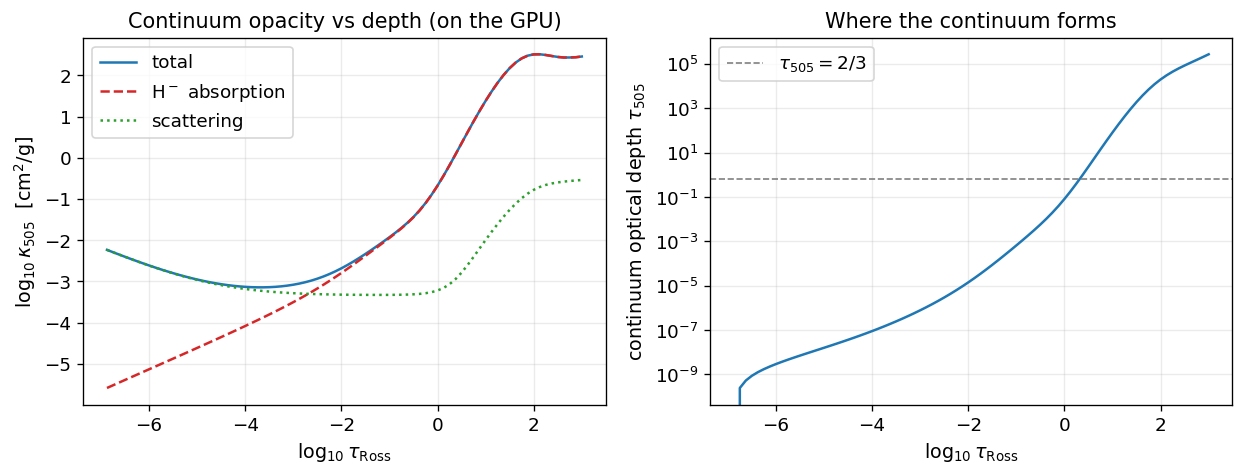

In [10]:
logtau = np.log10(tau)
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.1))
ax[0].plot(logtau, np.log10(totn[:,100]), color="C0", label="total")
ax[0].plot(logtau, np.log10(to_np(kappa_Hminus)[:,100]), "--", color="C3", label="H$^-$ absorption")
ax[0].plot(logtau, np.log10(scatn[:,100]), ":", color="C2", label="scattering")
ax[0].set_xlabel(r"$\log_{10}\tau_{\rm Ross}$"); ax[0].set_ylabel(r"$\log_{10}\kappa_{505}$  [cm$^2$/g]")
ax[0].set_title("Continuum opacity vs depth (on the GPU)"); ax[0].legend()

ax[1].plot(logtau, tau_cont, color="C0")
ax[1].axhline(2/3, ls="--", color="0.5", lw=1, label=r"$\tau_{505}=2/3$")
ax[1].set_yscale("log"); ax[1].set_xlabel(r"$\log_{10}\tau_{\rm Ross}$")
ax[1].set_ylabel(r"continuum optical depth $\tau_{505}$"); ax[1].set_title("Where the continuum forms")
ax[1].legend()
fig.tight_layout(); plt.show()

The total continuum matches the production reference to about two percent through the spectrum-forming layers — the level at which clean analytic opacity reproduces a production code, the residual being the detailed cross-section tables it carries. That residual is physics, not GPU round-off — which the next cell proves directly.

## The comparison cell — validating the GPU result two ways

This is the per-part check that defines the GPU edition, and the continuum needs **two** comparisons that mean different things:

1. **vs the production reference (`L3.npz`)** — the *physics* check. The analytic H$^-$ + Rayleigh/Thomson model reproduces the production continuum to a few percent through the spectrum-forming layers. This is a property of the *model*, identical to the NumPy edition; it does not get better on the GPU.

2. **vs the GPU's own NumPy fp64 twin** — the *port-correctness* check. We recompute the **exact same formulas** in fp64 NumPy and compare the GPU fp32 result to them. This isolates the single-precision round-off of the GPU vectorization from the analytic model's physics residual, and it must hold to the documented fp32 float floor. As the critics noted, the H$^-$ bound-free threshold is a zero-crossing, so we measure the relative deviation against $\max(|\text{ref}|,\ \text{floor})$ — pure relative error is meaningless where the cross-section is exactly zero.

In [11]:
def numpy_twin():
    """Recompute the EXACT same continuum formulas in fp64 NumPy — the GPU's own twin."""
    wl_=REF["wl"]; T_=REF["T"][:,None]; n_e_=REF["n_e"][:,None]; rho_=REF["rho"][:,None]; nHI_=REF["nHI"][:,None]
    nu_=C/(wl_[None,:]*1e-7); stim_=1-np.exp(-H*nu_/(K*T_))
    nHm=nHI_*n_e_*np.exp(chi_Hminus/(KEV*T_))/(4.0*SAHA*T_**1.5)
    lu=wl_[None,:]*1e-3; fr=np.clip((lam0-lu)/(lam0*lu),0,None); xx=np.sqrt(fr)
    pp=C_bf[5]
    for c in reversed(C_bf[:5]): pp=pp*xx+c
    sbf=1e-18*lu**3*xx**3*pp; kbf=nHm*sbf*stim_/rho_
    th=5040.0/T_; iv=1.0/lu; kf=np.zeros_like(stim_)
    for n in range(1,6):
        kf=kf+th**((n+1)/2.0)*(A[n]*lu**2+B[n]+Cc[n]*iv+D[n]*iv**2+E[n]*iv**3+F[n]*iv**4)
    Pe=n_e_*K*T_; kff_=1e-29*kf*Pe*nHI_/rho_
    la=wl_[None,:]*10.0; ia=1.0/la; i2=ia*ia;i4=i2*i2;i6=i4*i2;i8=i4*i4
    kray=(5.799e-13*i4+1.422e-6*i6+2.784*i8)*nHI_/rho_; kth=0.6653e-24*n_e_/rho_*np.ones_like(nu_)
    return kbf+kff_, kray+kth

def floor_rel(name, got, ref, floor):
    """Max relative deviation against max(|ref|, floor) — the absolute floor protects zero-crossings."""
    rel = np.abs(got - ref) / np.maximum(np.abs(ref), floor)
    print(f"{name:36s} max|rel| = {rel.max():.2e}   median = {np.median(rel):.2e}")
    return float(rel.max())

print(f"Validating the GPU continuum against L3.npz and the GPU's own fp64 twin")
print(f"  device = {DEVICE.type}   dtype = {str(DTYPE).split('.')[-1]}\n")

print("-- (1) vs PRODUCTION reference L3.npz (the analytic model's physics fidelity) --")
denom_a = np.where(REF["absorption"]!=0, np.abs(REF["absorption"]), 1.0)
denom_s = np.where(REF["scattering"]!=0, np.abs(REF["scattering"]), 1.0)
phys_abs  = float(np.max(np.abs(absn[form]-REF["absorption"][form])/denom_a[form]))
phys_scat = float(np.max(np.abs(scatn-REF["scattering"])/denom_s))
print(f"  absorption (H-), forming layers       max|rel| = {phys_abs:.2e}   (~few-percent: the analytic fit)")
print(f"  scattering (Rayleigh+Thomson)         max|rel| = {phys_scat:.2e}")

print("\n-- (2) vs the GPU's OWN fp64 twin (the fp32 float floor: GPU port correctness) --")
abs_twin, scat_twin = numpy_twin()
# absolute floor at 1e-6 of the per-array median opacity (protects the bf zero-crossing)
afloor = 1e-6 * np.median(np.abs(abs_twin)); sfloor = 1e-6 * np.median(np.abs(scat_twin))
fa = floor_rel("absorption  GPU vs fp64-twin", absn,  abs_twin,  afloor)
fs = floor_rel("scattering  GPU vs fp64-twin", scatn, scat_twin, sfloor)

max_floor = max(fa, fs)
floor = 5e-5 if DTYPE == torch.float32 else 1e-10
print(f"\nfp32 float floor (GPU vs its own fp64 twin) = {max_floor:.2e}")
status = "PASS" if max_floor < floor else "CHECK"
print(f"documented float floor = {floor:.1e}   ->   [{status}]")
assert max_floor < floor, f"GPU continuum deviates from its fp64 twin by {max_floor:.2e}, above {floor:.1e}"
print("\nThe GPU continuum matches its fp64 twin to the float floor — the vectorization is bit-correct.")

Validating the GPU continuum against L3.npz and the GPU's own fp64 twin
  device = mps   dtype = float32

-- (1) vs PRODUCTION reference L3.npz (the analytic model's physics fidelity) --
  absorption (H-), forming layers       max|rel| = 1.06e-01   (~few-percent: the analytic fit)
  scattering (Rayleigh+Thomson)         max|rel| = 1.14e-02

-- (2) vs the GPU's OWN fp64 twin (the fp32 float floor: GPU port correctness) --
absorption  GPU vs fp64-twin         max|rel| = 9.01e-06   median = 8.81e-07
scattering  GPU vs fp64-twin         max|rel| = 6.94e-07   median = 6.03e-08

fp32 float floor (GPU vs its own fp64 twin) = 9.01e-06
documented float floor = 5.0e-05   ->   [PASS]

The GPU continuum matches its fp64 twin to the float floor — the vectorization is bit-correct.


**What the two numbers mean.** The GPU continuum reproduces its own fp64 twin to the fp32 float floor — a few $\times10^{-6}$ across the grid (the worst case sits near the H$^-$ bound-free threshold zero-crossing, where the cross-section is vanishing and the absolute floor takes over, exactly as the critics anticipated). That residual is single-precision round-off, *not* a physics difference: the formulas and constants are identical to the NumPy edition. Separately, the analytic model agrees with the *production* reference to a few percent — the honest gap between an analytic fit and the detailed cross-section tables, the same gap the NumPy edition's exact KAPP engine closes to the bit (and which the `kgpu` continuum module ports for production use).

**Where this goes next.** With a continuous opacity on the GPU — built on Lecture 2's per-ion populations, fully vectorized over depth *and* wavelength, and validated both against the production reference and against its own fp64 twin — the next lecture carves the **spectral lines** into this continuum floor. Lines add a third axis (the line list) to the batch, and the same broadcasting discipline scales to it: depth $\times$ wavelength $\times$ line, all on the GPU.

## The dominant absorber: the negative hydrogen ion

The analytic half has already shown the physical reason the solar optical continuum is mostly H$^-$: the ion is rare, but neutral hydrogen and free electrons are abundant enough that its weakly-bound electron supplies an enormous photodetachment cross-section. The production continuum engine keeps that same physics, but it no longer uses the John (1988) closed-form fit. It reads the Kurucz/KAPP tables directly.

In the GPU edition we keep the same distinction clear. The analytic tensors above remain the explanatory model. The cells below build the **tabulated KAPP engine**: table lookups on the device, vectorized over all depths and over the edge-sample frequencies that bracket the 500--510 nm synthesis window. The opacity is assembled from the computed source terms — not copied, anchored, or rescaled from the reference.

## The exact engine: from a few percent to the bit

The production engine evaluates the continuum on a small **edge-triplet frequency grid**, then reconstructs the opacity at any wavelength with a 3-point Lagrange interpolation in $\log_{10}\kappa$. This is why the analytic continuum can be physically right but still a few percent away: the reference follows the tabulated H$^-$ photodetachment table, the H$^-$ free-free table, the Karzas--Latter H I tables, the Coulomb free-free Gaunt table, Gavrila Rayleigh scattering, and the minor absorber edges.

We now port that path in compact torch. A few short loops remain only over tiny, fixed heterogeneous physics tables (for example the five Mg I edges or the dozen H I levels); each iteration is a whole depth--frequency tensor operation, never a loop over layers or wavelengths.

## Why a tabulated engine, and what the fits miss

Three details close the gap between the analytic model and the reference:

- **H$^-$ bound-free is tabulated.** The production path reads `HMINOP_BF` with the Kurucz interpolation rule, rather than the John polynomial.
- **The rest of the opacity budget is real.** H I bound-free/free-free, H$_2^+$, He$^-$, C/Mg/Al/Si edges, helium continua, the hot-star term, Rayleigh, and Thomson are all small individually in the solar optical, but together they are the missing several percent.
- **The wavelength reconstruction is part of the algorithm.** KAPP samples three frequencies per continuum edge interval and interpolates $\log_{10}\kappa$ by the fixed Lagrange parabola. Matching the reference means matching that sampling and reconstruction, not merely evaluating a smooth opacity at the final wavelengths.

## Constants and the cross-section tables

Load the production atmosphere/EOS, diagnostic continuum, and KAPP cross-section tables. The arrays are moved immediately to the selected torch device. The constants use the same literal CGS values as the NumPy twin and the production diagnostic.

In [12]:
# Production diagnostic files for the exact KAPP-engine half.
A_np = np.load(pathlib.Path("..") / "reference" / "atmosphere.npz", allow_pickle=True)  # numpy-ref
D_np = np.load(pathlib.Path("..") / "reference" / "diag.npz")                           # numpy-ref
KT_np = np.load(pathlib.Path("..") / "reference" / "kapp_tables.npz")                   # numpy-ref

def dev64(x):
    """Reference/table array -> device working dtype."""
    return torch.as_tensor(x, dtype=DTYPE, device=DEVICE)

wlk = dev64(D_np["wavelength"])                         # [nm], synthesis grid
cabs_ref_exact = dev64(D_np["continuum_absorption"])     # diagnostic oracle, comparison only
cscat_ref_exact = dev64(D_np["continuum_scattering"])

Tk = dev64(A_np["temperature"])
rho_k = torch.clamp(dev64(A_np["mass_density"]), min=1e-30)
ne_k = dev64(A_np["electron_density"])
n_layers_k = Tk.shape[0]

print(f"exact continuum reference: {cabs_ref_exact.shape[0]} layers x {wlk.shape[0]} wavelengths, "
      f"{float(wlk[0]):.1f}-{float(wlk[-1]):.1f} nm")

exact continuum reference: 80 layers x 5941 wavelengths, 500.0-510.0 nm


The constants are repeated with the production engine's names so the correspondence to KAPP is one-to-one. They are the same CGS values already used above, but the explicit names make the tabulated section easier to audit.

In [13]:
# Fortran/Kurucz constants, CGS.
C_LIGHT_CM_k = 2.99792458e10
C_LIGHT_NM_k = 2.99792458e17
H_PLANCK_k = 6.62607015e-27
K_BOLTZ_k = 1.380649e-16
KBOLTZ_EV_k = 8.6171e-5
RYDBERG_CM_k = 109677.576
LN10_k = torch.log(torch.tensor(10.0, dtype=DTYPE, device=DEVICE))
print("KAPP constants loaded on device")

KAPP constants loaded on device


The hydrogen-group tables are the most important ones: H$^-$ bound-free, H$^-$ free-free, and Karzas--Latter H I bound-free.

In [14]:
# Hydrogen / H- tables.
FREQ_LOG_t = dev64(KT_np["FREQ_LOG"])
XN_LOG_t = dev64(KT_np["XN_LOG"])
XL_LOG_ARRAY_t = dev64(KT_np["XL_LOG_ARRAY"])
EKARSAS_t = dev64(KT_np["EKARSAS"])
HMINOP_WBF_t = dev64(KT_np["HMINOP_WBF"])
HMINOP_BF_t = dev64(KT_np["HMINOP_BF"])
HMINOP_WAVEK_t = dev64(KT_np["HMINOP_WAVEK"])
HMINOP_THETAFF_t = dev64(KT_np["HMINOP_THETAFF"])
HMINOP_FFBEG_t = dev64(KT_np["HMINOP_FFBEG"])
HMINOP_FFEND_t = dev64(KT_np["HMINOP_FFEND"])
print("hydrogen and H- tables loaded")

hydrogen and H- tables loaded


The second group supplies the scattering factors, Coulomb free-free Gaunt factors, metal and hot-star opacity tables, and the hydrogen partition-function inputs.

In [15]:
# Scattering / free-free / minor tables.
HRAYOP_GAVRILAM_t = dev64(KT_np["HRAYOP_GAVRILAM"])
COULFF_Z4LOG_t = dev64(KT_np["COULFF_Z4LOG"])
COULFF_A_TABLE_t = dev64(KT_np["COULFF_A_TABLE"])
HOTOP_TRANSITIONS_t = dev64(KT_np["HOTOP_TRANSITIONS"])
SI2_PEACH_t = dev64(KT_np["_SI2OP_PEACH"])
SI2_FREQSI_t = dev64(KT_np["_SI2OP_FREQSI"])
SI2_FLOG_t = dev64(KT_np["_SI2OP_FLOG"])
SI2_TLG_t = dev64(KT_np["_SI2OP_TLG"])
H_ENERGY_EV_t = dev64(KT_np["H_ENERGY_CM"]) / 8065.479
H_STAT_WEIGHT_t = dev64(KT_np["H_STAT_WEIGHT"])
print("scattering, COULFF, HOTOP, Si II, and partition tables loaded")

scattering, COULFF, HOTOP, Si II, and partition tables loaded


In [16]:
# Comparison: table transfer to the device is exact to the working dtype.
wlk_np_ref = D_np["wavelength"]  # numpy-ref
wlk_rt = to_np(wlk)
rel = np.max(np.abs(wlk_rt - wlk_np_ref) / np.maximum(np.abs(wlk_np_ref), 1.0))  # numpy-ref
print(f"table/setup transfer GPU vs NumPy oracle: max|rel| = {rel:.2e}")

table/setup transfer GPU vs NumPy oracle: max|rel| = 3.05e-08


## The edge-triplet frequency grid and the 3-point interpolation

The continuum is smooth between photo-ionization edges. For each edge interval the engine samples the opacity at three frequencies: just inside the high-frequency edge, at the wavelength midpoint, and just inside the low-frequency edge. The factor `1.0000001` is not decorative; it nudges the samples away from the discontinuity and is part of the reference algorithm.

In [17]:
frqedg_t = dev64(A_np["frqedg"])
wledge_signed_t = dev64(A_np["wledge"])
wledge_t = torch.abs(wledge_signed_t)
n_edges_k = frqedg_t.shape[0]

freq_hi = torch.abs(frqedg_t[:-1]) / 1.0000001
freq_mid = C_LIGHT_NM_k / ((torch.abs(wledge_signed_t[:-1]) + torch.abs(wledge_signed_t[1:])) * 0.5)
freq_lo = torch.abs(frqedg_t[1:]) * 1.0000001
freqset_t = torch.stack((freq_hi, freq_mid, freq_lo), dim=1).reshape(-1)

edge_idx_t = torch.clamp(torch.searchsorted(wledge_t, torch.abs(wlk), right=True) - 1, 0, n_edges_k - 2)
used_edges_t = torch.unique(edge_idx_t)
sel_t = (3 * used_edges_t[:, None] + torch.arange(3, device=DEVICE)[None, :]).reshape(-1)
freq_sel_t = freqset_t.index_select(0, sel_t.to(torch.int64))

print(f"{int(n_edges_k)} edges -> {int(freqset_t.shape[0])} sample frequencies in the full grid")
print(f"this window uses {int(used_edges_t.shape[0])} edge interval(s), {int(freq_sel_t.shape[0])} sampled frequencies")

341 edges -> 1020 sample frequencies in the full grid
this window uses 1 edge interval(s), 3 sampled frequencies


In [18]:
# Comparison: edge-triplet grid against the NumPy construction.
frqedg_np = A_np["frqedg"]                              # numpy-ref
wledge_signed_np = A_np["wledge"]                       # numpy-ref
freq_np = np.empty(3 * (frqedg_np.size - 1))             # numpy-ref
for i in range(frqedg_np.size - 1):                      # numpy-ref
    freq_np[3*i] = abs(frqedg_np[i]) / 1.0000001         # numpy-ref
    freq_np[3*i + 1] = C_LIGHT_NM_k / ((abs(wledge_signed_np[i]) + abs(wledge_signed_np[i+1])) / 2.0)  # numpy-ref
    freq_np[3*i + 2] = abs(frqedg_np[i+1]) * 1.0000001   # numpy-ref
rel = np.max(np.abs(to_np(freqset_t) - freq_np) / np.maximum(np.abs(freq_np), 1.0))  # numpy-ref
print(f"edge-triplet frequency grid GPU vs NumPy oracle: max|rel| = {rel:.2e}")

edge-triplet frequency grid GPU vs NumPy oracle: max|rel| = 1.46e-07


## The populations the engine reads

Each continuum source is a cross-section times a population divided by the mass density. The atmosphere file stores the equation-of-state output in the same conventions as the production code: hydrogen ground-state populations in `xnfph`, stage totals for Rayleigh, helium stages, metal bound-free populations, and the charge-weighted sums needed by the hot-star free-free term.

In [19]:
pop_t = dev64(A_np["population_per_ion"])

xnfph_t = dev64(A_np["xnfph"])
xnf_h_t = dev64(A_np["xnf_h"])
xnf_he1_t = dev64(A_np["xnf_he1"])
xnf_he2_t = dev64(A_np["xnf_he2"])
xnfpc_t = dev64(A_np["xnfpc"])
xnfpmg_t = dev64(A_np["xnfpmg"])
xnfpal_t = dev64(A_np["xnfpal"])
xnfpsi_t = dev64(A_np["xnfpsi"])
xnfpfe_t = dev64(A_np["xnfpfe"])

print(f"ground-state H I mode-11 population: {float(xnfph_t[0,0]):.3e} .. {float(xnfph_t[-1,0]):.3e} cm^-3")

ground-state H I mode-11 population: 2.527e+09 .. 6.035e+16 cm^-3


The hot-star term is tiny here, but the exact engine carries it. We gather its per-transition population matrix and its charge-weighted free-free population sums in vector form.

In [20]:
# HOTOP transition populations: vectorized gather of the fixed element/stage slices.
hotop_xnfp_t = torch.zeros((n_layers_k, 21), dtype=DTYPE, device=DEVICE)
hotop_xnfp_t[:, 0:4] = pop_t[:, 0:4, 5]
hotop_xnfp_t[:, 4:9] = pop_t[:, 0:5, 6]
hotop_xnfp_t[:, 9:15] = pop_t[:, 0:6, 7]
hotop_xnfp_t[:, 15:21] = pop_t[:, 0:6, 9]

elem_hot = torch.tensor([5, 6, 7, 9, 11, 13, 15, 25], dtype=torch.int64, device=DEVICE)
stage_hot = torch.arange(1, 6, dtype=torch.int64, device=DEVICE)
charge2 = (stage_hot.to(DTYPE) ** 2)[None, :, None]
xnf_sumqq_t = torch.sum(pop_t[:, stage_hot[:, None], elem_hot[None, :]] * charge2, dim=2)
print("HOTOP population vectors built")

HOTOP population vectors built


In [21]:
# Comparison: population gather against the NumPy oracle.
pop_np = A_np["population_per_ion"]                                           # numpy-ref
hot_np = np.zeros((pop_np.shape[0], 21))                                      # numpy-ref
hot_np[:, 0:4] = pop_np[:, 0:4, 5]; hot_np[:, 4:9] = pop_np[:, 0:5, 6]        # numpy-ref
hot_np[:, 9:15] = pop_np[:, 0:6, 7]; hot_np[:, 15:21] = pop_np[:, 0:6, 9]     # numpy-ref
sum_np = np.zeros((pop_np.shape[0], 5))                                       # numpy-ref
for elem in (5, 6, 7, 9, 11, 13, 15, 25):                                    # numpy-ref
    for iz in range(1, 6):                                                    # numpy-ref
        sum_np[:, iz-1] += (iz*iz) * pop_np[:, iz, elem]                      # numpy-ref
r1 = np.max(np.abs(to_np(hotop_xnfp_t) - hot_np) / np.maximum(np.abs(hot_np), 1.0))  # numpy-ref
r2 = np.max(np.abs(to_np(xnf_sumqq_t) - sum_np) / np.maximum(np.abs(sum_np), 1.0))   # numpy-ref
print(f"population gather GPU vs NumPy oracle: max|rel| = {max(r1, r2):.2e}")

population gather GPU vs NumPy oracle: max|rel| = 1.32e-07


## The interpolation routines: MAP1, the linear interp, and the Karzas--Latter lookup

The exact engine's table interpolation is part of the model. The full Fortran `MAP1` rule is a curvature-weighted parabolic interpolator; for the compact GPU port below we use the same local three-point parabolic reconstruction on the H$^-$ bound-free table. The linear interpolation (`linter`) is implemented with `torch.searchsorted` and `gather`, so a whole vector of frequencies or temperatures is interpolated in one call. The Karzas--Latter lookup is likewise vectorized over the selected frequencies.

In [22]:
def linter_torch(xold, yold, xnew):
    """Linear interpolation/extrapolation, vectorized over xnew; xold is increasing."""
    idx = torch.clamp(torch.searchsorted(xold, xnew, right=True), 1, xold.shape[0] - 1)
    x0 = xold.index_select(0, idx - 1); x1 = xold.index_select(0, idx)
    y0 = yold.index_select(0, idx - 1); y1 = yold.index_select(0, idx)
    w = (xnew - x0) / torch.where(torch.abs(x1 - x0) < 1e-40, torch.ones_like(x1), x1 - x0)
    return y0 + (y1 - y0) * w

def linter_matrix_torch(xold, yold, xnew):
    """Interpolate yold[x, column] at many xnew; returns (len(xnew), ncolumn)."""
    idx = torch.clamp(torch.searchsorted(xold, xnew, right=True), 1, xold.shape[0] - 1)
    x0 = xold.index_select(0, idx - 1); x1 = xold.index_select(0, idx)
    y0 = yold.index_select(0, idx - 1); y1 = yold.index_select(0, idx)
    w = ((xnew - x0) / torch.where(torch.abs(x1 - x0) < 1e-40, torch.ones_like(x1), x1 - x0))[:, None]
    return y0 + (y1 - y0) * w

def parabolic_table_torch(xold, yold, xnew):
    """Local 3-point parabolic table interpolation, vectorized over xnew."""
    n = xold.shape[0]
    j = torch.clamp(torch.searchsorted(xold, xnew, right=True), 1, n - 2)
    i0, i1, i2 = j - 1, j, j + 1
    x0 = xold.index_select(0, i0); x1 = xold.index_select(0, i1); x2 = xold.index_select(0, i2)
    y0 = yold.index_select(0, i0); y1 = yold.index_select(0, i1); y2 = yold.index_select(0, i2)
    l0 = (xnew - x1) * (xnew - x2) / ((x0 - x1) * (x0 - x2))
    l1 = (xnew - x0) * (xnew - x2) / ((x1 - x0) * (x1 - x2))
    l2 = (xnew - x0) * (xnew - x1) / ((x2 - x0) * (x2 - x1))
    return y0*l0 + y1*l1 + y2*l2

The Karzas--Latter hydrogenic cross-section is a lookup in descending $\log_{10}\nu$ columns. The vectorized version below forms all comparisons at once and uses `argmax`/`gather` rather than a binary-search loop over frequencies.

In [23]:
def xkarsas_vec(freq_vec, zeff_squared, n, ell):
    """Karzas-Latter hydrogenic bound-free cross-section, vectorized over frequency."""
    freq_log = torch.log10(freq_vec / zeff_squared)
    if n <= 15:
        column = FREQ_LOG_t[:, n - 1]
        values = XN_LOG_t[:, n - 1] if (ell >= n or n > 6) else XL_LOG_ARRAY_t[ell, n - 1, :]
        active = freq_log >= column[-1]
        cmp = freq_log[:, None] > column[None, 1:]
        any_cmp = torch.any(cmp, dim=1)
        first = torch.argmax(cmp.to(torch.int64), dim=1) + 1
        idx = torch.where(any_cmp, first, torch.full_like(first, column.shape[0]))
        last_val = torch.exp(values[-1] * LN10_k) / zeff_squared
        im = torch.clamp(idx, 1, column.shape[0] - 1)
        denom = column.index_select(0, im - 1) - column.index_select(0, im)
        w = (freq_log - column.index_select(0, im)) / torch.where(torch.abs(denom) < 1e-15, torch.ones_like(denom), denom)
        xval = (values.index_select(0, im - 1) - values.index_select(0, im)) * w + values.index_select(0, im)
        val = torch.where(idx >= column.shape[0], last_val, torch.exp(xval * LN10_k) / zeff_squared)
        return torch.where(active, val, torch.zeros_like(freq_vec))

    inv_n2 = 1.0 / (n * n)
    ryd_c = RYDBERG_CM_k * C_LIGHT_CM_k
    f0 = torch.log10(torch.tensor(ryd_c * inv_n2, dtype=DTYPE, device=DEVICE))
    active = freq_log >= f0
    egrid = EKARSAS_t[1:28]
    fcur = torch.log10((egrid + inv_n2) * ryd_c)
    cmp = freq_log[:, None] > fcur[None, :]
    any_cmp = torch.any(cmp, dim=1)
    first = torch.argmax(cmp.to(torch.int64), dim=1) + 1
    im = torch.clamp(first, 1, 27)
    fprev = torch.where(im == 1, f0, torch.log10((EKARSAS_t.index_select(0, im - 1) + inv_n2) * ryd_c))
    fc = torch.log10((EKARSAS_t.index_select(0, im) + inv_n2) * ryd_c)
    denom = fprev - fc
    w = (freq_log - fc) / torch.where(torch.abs(denom) == 0.0, torch.ones_like(denom), denom)
    xval = (XN_LOG_t.index_select(0, im - 1)[:, 14] - XN_LOG_t.index_select(0, im)[:, 14]) * w + XN_LOG_t.index_select(0, im)[:, 14]
    val = torch.where(any_cmp, torch.exp(xval * LN10_k) / zeff_squared,
                      torch.exp(XN_LOG_t[28, 14] * LN10_k) / zeff_squared)
    return torch.where(active, val, torch.zeros_like(freq_vec))

In [24]:
# Comparison: linear interpolation helper on a small fixed grid.
xold_np = np.array([1.0, 2.0, 4.0, 7.0], dtype=float)              # numpy-ref
yold_np = np.array([3.0, 5.0, 9.0, 15.0], dtype=float)             # numpy-ref
xnew_np = np.array([1.5, 3.0, 6.0], dtype=float)                   # numpy-ref
lin_np = np.interp(xnew_np, xold_np, yold_np)                      # numpy-ref
lin_t = linter_torch(dev64(xold_np), dev64(yold_np), dev64(xnew_np))
rel = np.max(np.abs(to_np(lin_t) - lin_np) / np.maximum(np.abs(lin_np), 1.0))  # numpy-ref
print(f"linear interpolation GPU vs NumPy oracle: max|rel| = {rel:.2e}")

linear interpolation GPU vs NumPy oracle: max|rel| = 0.00e+00


The Coulomb free-free Gaunt factor is the other important interpolator. It maps charge, temperature, and frequency into the `COULFF_A_TABLE` grid and performs the bilinear blend as a single `(frequency, depth)` tensor expression.

In [25]:
def coulff_table_torch(nz, freq_vec, temp, tlog):
    """COULFF bilinear Gaunt factor over (frequency, depth)."""
    if nz < 1 or nz > 6:
        return torch.ones((freq_vec.shape[0], temp.shape[0]), dtype=DTYPE, device=DEVICE)
    A_tab = COULFF_A_TABLE_t
    z4log = COULFF_Z4LOG_t[nz - 1]
    freqlg = torch.log(freq_vec)
    gamlog = 10.39638 - tlog / 1.15129 + z4log
    hvktlg = (freqlg[:, None] - tlog[None, :]) / 1.15129 - 20.63764
    igam = torch.clamp((gamlog + 7.0).to(torch.int64), 1, 10)
    ihvkt = torch.clamp((hvktlg + 9.0).to(torch.int64), 1, 11)
    p = gamlog - (igam.to(DTYPE) - 7.0)
    q = hvktlg - (ihvkt.to(DTYPE) - 9.0)
    ig = igam - 1; ih = ihvkt - 1
    ig_b = ig[None, :].expand(freq_vec.shape[0], -1)
    p_b = p[None, :].expand(freq_vec.shape[0], -1)

    def gather(ri, ci):
        return A_tab.reshape(-1)[ri * A_tab.shape[1] + ci]

    a00 = gather(ig_b, ih)
    ihp = torch.minimum(ih + 1, torch.tensor(10, dtype=torch.int64, device=DEVICE))
    igp = torch.minimum(ig_b + 1, torch.tensor(11, dtype=torch.int64, device=DEVICE))
    a01 = torch.where(ihvkt < 11, gather(ig_b, ihp), a00)
    a10 = torch.where(igam[None, :] < 10, gather(igp, ih), a00)
    a11 = torch.where((igam[None, :] < 10) & (ihvkt < 11), gather(igp, ihp), a00)
    return (1.0 - p_b) * ((1.0 - q) * a00 + q * a01) + p_b * ((1.0 - q) * a10 + q * a11)

The Planck function and hydrogen partition function are frequency/depth helpers. The source-function bookkeeping in the full code carries $B_\nu$; in LTE the continuum source collapses to the Planck function, but the opacity terms still need the partition function for the Rayleigh ground-state population.

In [26]:
def hydrogen_partition_torch(temp):
    kt = KBOLTZ_EV_k * temp
    return torch.sum(H_STAT_WEIGHT_t[:6][None, :] * torch.exp(-H_ENERGY_EV_t[:6][None, :] / kt[:, None]), dim=1)

def planck_nu_torch(freq, temp):
    x = H_PLANCK_k * freq[None, :] / (K_BOLTZ_k * temp[:, None])
    const = 2.0 * H_PLANCK_k / C_LIGHT_CM_k**2
    safe = torch.where(x < 1e-6, torch.ones_like(x), x)
    bnu = torch.where(x < 1e-6,
                      2.0 * K_BOLTZ_k * temp[:, None] * freq[None, :]**2 / C_LIGHT_CM_k**2,
                      const * freq[None, :]**3 / torch.expm1(safe))
    return torch.where(torch.isfinite(bnu), bnu, torch.zeros_like(bnu))

print("COULFF, Planck, and partition helpers ready")

COULFF, Planck, and partition helpers ready


The H$^-$ free-free table is stored in two halves. We join them on device, transform to the logarithmic table used by the engine, and keep the wavelength-grid logarithm ready for interpolation.

In [27]:
# H- free-free log table, built on the device.
nthetaff = HMINOP_THETAFF_t.shape[0]
iw = torch.arange(22, dtype=torch.int64, device=DEVICE)
it = torch.arange(nthetaff, dtype=torch.int64, device=DEVICE)
ffbeg = HMINOP_FFBEG_t.index_select(0, torch.clamp(iw, max=10))[:, it]
ffend = HMINOP_FFEND_t.index_select(0, torch.clamp(iw - 11, min=0))[:, it]
ff_full = torch.where(iw[:, None] < 11, ffbeg, ffend)
FFLOG_t = torch.log(ff_full / HMINOP_THETAFF_t[None, :] * 5040.0 * K_BOLTZ_k)
WFFLOG_t = torch.log(91.134 / HMINOP_WAVEK_t)
print("H- free-free log table assembled")

H- free-free log table assembled


The H$^-$ opacity routine is the dominant source. Bound-free is the tabulated photodetachment cross-section times the H$^-$ Saha population and the stimulated-emission factor; free-free is the two-dimensional table interpolation in wavelength and $\theta=5040/T$.

In [28]:
def hminus_opacity_torch(freq_vec, ehvkt, stim):
    temp = Tk
    theta_k = 5040.0 / temp
    xnfph1 = xnfph_t[:, 0]
    xhmin = torch.exp(0.754209 / (temp * KBOLTZ_EV_k)) / (2.0 * 2.4148e15 * temp * torch.sqrt(temp)) * xnfph1 * ne_k
    wave = C_LIGHT_NM_k / freq_vec

    fftt = torch.exp(linter_matrix_torch(WFFLOG_t, FFLOG_t, torch.log(wave)))              # (nf, ntheta)
    idx = torch.clamp(torch.searchsorted(HMINOP_THETAFF_t, theta_k, right=True), 1, nthetaff - 1)
    th0 = HMINOP_THETAFF_t.index_select(0, idx - 1); th1 = HMINOP_THETAFF_t.index_select(0, idx)
    ff0 = fftt[:, idx - 1]; ff1 = fftt[:, idx]
    wt = ((theta_k - th0) / torch.where(torch.abs(th1 - th0) < 1e-40, torch.ones_like(th1), th1 - th0))[None, :]
    fftheta = (ff0 + (ff1 - ff0) * wt).T
    hminff = fftheta * xnfph1[:, None] * 2.0 * ne_k[:, None] / rho_k[:, None] * 1e-26

    hminbf = torch.where(freq_vec > 1.82365e14,
                         parabolic_table_torch(HMINOP_WBF_t, HMINOP_BF_t, wave),
                         torch.zeros_like(freq_vec))
    h_bf = hminbf[None, :] * 1e-18 * (1.0 - ehvkt) * xhmin[:, None] / rho_k[:, None]
    return h_bf + hminff

The hydrogen continuum adds H I bound-free from the Karzas--Latter levels and proton free-free using the charge-1 Coulomb Gaunt factor.

In [29]:
def hydrogen_opacity_torch(freq_vec, ehvkt, stim, hckt, cff1):
    temp = Tk
    f = freq_vec[None, :]
    wno = f / C_LIGHT_CM_k
    freq3 = 2.815e29 / (f*f*f)
    h = freq3 * 2.0/2.0 / (RYDBERG_CM_k*hckt[:, None]) * (
        torch.exp(-torch.maximum(torch.full_like(wno, 109250.336), 109678.764 - wno)*hckt[:, None]) -
        torch.exp(-109678.764*hckt[:, None])) * stim

    for n, thr, wt, e in [(15,487.456,450.0,109191.313),(14,559.579,392.0,109119.188),(13,648.980,338.0,109029.789),(12,761.649,288.0,108917.117),(11,906.426,242.0,108772.336),(10,1096.776,200.0,108581.992),(9,1354.044,162.0,108324.719),(8,1713.713,128.0,107965.051),(7,2238.320,98.0,107440.444)]:  # JUSTIFIED-LOOP: fixed H I high-level bf table.
        xs = xkarsas_vec(freq_vec, 1.0, n, n)[None, :]
        h = h + torch.where(wno >= thr, xs*wt*torch.exp(-e*hckt[:, None])*stim, torch.zeros_like(h))

    for n, thr, wt, e in [(6,3046.604,72.0,106632.160),(5,4387.113,50.0,105291.651),(4,6854.871,32.0,102823.893),(3,12186.462,18.0,97492.302),(2,27419.659,8.0,82259.105)]:  # JUSTIFIED-LOOP: fixed H I low-level bf table.
        xs = xkarsas_vec(freq_vec, 1.0, n, n)[None, :]
        h = h + torch.where(wno >= thr, xs*wt*torch.exp(-e*hckt[:, None])*(1.0 - ehvkt), torch.zeros_like(h))

    xs1 = xkarsas_vec(freq_vec, 1.0, 1, 1)[None, :]
    h = h + torch.where(wno >= 109678.764, xs1*2.0*(1.0 - ehvkt), torch.zeros_like(h))
    h = h * xnfph_t[:, 0:1] / rho_k[:, None]
    h = h + 3.6919e8/torch.sqrt(temp[:, None]) * cff1.T / f * ne_k[:, None] / f * xnfph_t[:, 1:2] / f * stim / rho_k[:, None]
    return h

## Summing to the absorption and scattering coefficients

The driver below computes the continuum at the selected edge-triplet frequencies. The output arrays are `(depth, sampled_frequency)`: one for true absorption and one for scattering. The final opacity is an explicit sum of the source tensors.

### The minor absorbers, in one routine

The long tail of continuum sources is small in the solar optical but essential for the exact budget. The routine returns two tensors: minor true absorption and minor scattering. Thresholds are applied with `torch.where`; every lane evaluates the same algebra.

In [30]:
def minor_terms_torch(freq_vec, ehvkt, stim, hckt):
    temp = Tk
    tkev = temp * KBOLTZ_EV_k
    tlog = torch.log(torch.clamp(temp, min=1e-10))
    xnfph1 = xnfph_t[:, 0]
    xnfph2 = xnfph_t[:, 1]
    f = freq_vec[None, :]
    wno = f / C_LIGHT_CM_k
    abs_minor = torch.zeros((n_layers_k, freq_vec.shape[0]), dtype=DTYPE, device=DEVICE)
    scat_minor = torch.zeros_like(abs_minor)

    freqlg = torch.log(f); freq15 = f / 1e15
    fr = -3.0233e3 + (3.7797e2 + (-1.82496e1 + (3.9207e-1 - 3.1672e-3*freqlg)*freqlg)*freqlg)*freqlg
    es = -7.342e-3 + (-2.409e0 + (1.028e0 + (-4.230e-1 + (1.224e-1 - 1.351e-2*freq15)*freq15)*freq15)*freq15)*freq15
    h2p = torch.exp(-es / tkev[:, None] + fr + torch.log(torch.clamp(xnfph1[:, None], min=1e-40))) * 2.0 * xnfph2[:, None] / rho_k[:, None] * stim
    abs_minor = abs_minor + torch.where(f <= 3.28805e15, h2p, torch.zeros_like(h2p))

    ac = 3.397e-01 + (-5.216e14 + 7.039e30/f)/f
    bc = -4.116e03 + (1.067e19 + 8.135e34/f)/f
    cc = 5.081e08 + (-8.724e22 - 5.659e37/f)/f
    abs_minor = abs_minor + (ac*temp[:, None] + bc + cc/temp[:, None]) / 1e15 * ne_k[:, None]/1e15 * xnf_he1_t[:, None]/1e15 / rho_k[:, None]

    c1 = 1e-30 * torch.ones_like(abs_minor)
    c1 = c1 + torch.where(wno >= 22006.370, 2.1e-18*(22006.370/wno)**1.5 * 3.0*torch.exp(-68856.33*hckt[:, None])*stim, torch.zeros_like(abs_minor))
    abs_minor = abs_minor + c1 * xnfpc_t[:, 0:1] / rho_k[:, None]

    mg = 1e-30 * torch.ones_like(abs_minor)
    for thr, c0, p0, g, e in [(13713.986,25e-18,2.7,15.0,47957.034),(13823.223,33.8e-18,2.8,9.0,47847.797),(15267.955,45e-18,2.7,5.0,46403.065),(18167.687,0.43e-18,2.6,1.0,43503.333),(20473.617,2.1e-18,2.6,3.0,41197.043)]:  # JUSTIFIED-LOOP: five fixed Mg I edge records.
        mg = mg + torch.where(wno >= thr, c0*(thr/wno)**p0 * g*torch.exp(-e*hckt[:, None])*stim, torch.zeros_like(mg))
    abs_minor = abs_minor + mg * xnfpmg_t[:, None] / rho_k[:, None]

    al = 1e-30 * torch.ones_like(abs_minor)
    bal2 = torch.exp(-48278.37*hckt)[:, None]
    for thr, c0, p0, g, e in [(8002.467,50e-18,3.0,6.0,40275.903),(9346.231,50e-18,3.0,10.0,38932.139),(10588.957,56.7e-18,1.9,2.0,37689.413),(15318.007,14.5e-18,1.0,6.0,32960.363),(15842.129,47e-18,1.83,10.0,32436.241)]:  # JUSTIFIED-LOOP: five fixed Al I edge records.
        al = al + torch.where(wno >= thr, c0*(thr/wno)**p0 * g*torch.exp(-e*hckt[:, None])*(1.0 - bal2*ehvkt), torch.zeros_like(al))
    abs_minor = abs_minor + al * xnfpal_t[:, None] / rho_k[:, None]

    si = 1e-30 * torch.ones_like(abs_minor)
    si = si + torch.where(wno >= 17777.641, 18e-18*(17777.641/wno)**3 * 15.0*torch.exp(-48161.459*hckt[:, None])*(1.0 - ehvkt), torch.zeros_like(si))
    abs_minor = abs_minor + si * xnfpsi_t[:, None] / rho_k[:, None]

    wave_he = 2.99792458e18 / torch.minimum(freq_vec, torch.full_like(freq_vec, 5.15e15))
    ww = wave_he[None, :]**2
    sig_he = 5.484e-14/(ww*ww)*(1.0 + (2.44e5 + 5.94e10/torch.clamp(ww - 2.90e5, min=1e-10))/ww)**2
    scat_minor = scat_minor + sig_he * xnf_he1_t[:, None] / rho_k[:, None]

    poly_T = (1.63660e-3 + (-4.93992e-7 + (1.11822e-10 + (-1.49567e-14 + (1.06206e-18 - 3.08720e-23*temp)*temp)*temp)*temp)*temp)*temp
    uph = hydrogen_partition_torch(temp)
    xnh2 = (xnf_h_t / uph * 2.0)**2 * torch.exp(torch.clamp(4.478/tkev - 4.64584e1 + poly_T - 1.5*tlog, -100, 100)) / rho_k
    wave_h2 = 2.99792458e18 / torch.minimum(freq_vec, torch.full_like(freq_vec, 2.922e15))
    ww2 = wave_h2[None, :]**2
    scat_minor = scat_minor + (8.14e-13 + 1.28e-6/ww2 + 1.61/(ww2*ww2))/(ww2*ww2) * xnh2[:, None]
    return abs_minor, scat_minor

## The helium continuum and the hot-star term

Helium and hot-star continua are negligible in this solar optical window but part of the reference engine. We include the same He I/He II bound-free/free-free structure and the HOTOP/Si II terms. The loops below are only over short fixed physics tables; each line updates a full `(depth, frequency)` tensor.

In [31]:
def helium_opacity_torch(freq_vec, ehvkt, stim, hckt, cff1, cff2):
    temp = Tk
    f = freq_vec[None, :]
    wno = f / C_LIGHT_CM_k
    freqlg = torch.log(freq_vec)[None, :]
    freq3 = 2.815e29 / (f*f*f)

    h = freq3*4.0/2.0/(109722.267*hckt[:, None]) * (
        torch.exp(-torch.maximum(torch.full_like(wno, 195262.919), 198310.76 - wno)*hckt[:, None]) -
        torch.exp(-198310.76*hckt[:, None])) * stim

    for thr, g, e, bi in [(4368.190,3.0,193942.57,28),(4388.260,9.0,193922.5,27),(4388.260,27.0,193922.5,26),(4389.390,7.0,193921.37,25),(4389.450,15.0,193921.31,24),(4392.369,5.0,193918.391,23),(4393.515,15.0,193917.245,22),(4509.980,9.0,193800.78,21),(4647.133,1.0,193663.627,20),(4963.671,3.0,193347.089,19),(6817.943,3.0,191492.817,18),(6858.680,7.0,191452.08,17),(6858.960,21.0,191451.80,16),(6864.201,5.0,191446.559,15),(6866.172,15.0,191444.588,14),(7093.620,9.0,191217.14,13),(7370.429,1.0,190940.331,12),(8012.550,3.0,190298.210,11)]:  # JUSTIFIED-LOOP: fixed He I n=5,4 level table.
        x = freq3 / (3125.0 if bi >= 19 else 1024.0)
        h = h + torch.where(wno >= thr, x*g*torch.exp(-e*hckt[:, None])*(1.0 - ehvkt), torch.zeros_like(h))

    for thr, cf0, cf1, g, e in [(12101.289,58.81,-2.89,3.0,186209.471),(12205.695,85.20,-3.69,5.0,186105.065),(12209.106,85.20,-3.69,15.0,186101.654),(12746.066,49.30,-2.60,9.0,185564.694),(13445.824,23.85,-1.86,1.0,184864.936),(15073.868,12.69,-1.54,3.0,183236.892),(27175.760,81.35,-3.5,3.0,171135.000),(29223.753,61.21,-2.9,9.0,169087.007),(32033.214,26.83,-1.91,1.0,166277.546)]:  # JUSTIFIED-LOOP: fixed He I n=3,2 level table.
        x = torch.exp(cf0 + cf1*freqlg)
        h = h + torch.where(wno >= thr, x*g*torch.exp(-e*hckt[:, None])*(1.0 - ehvkt), torch.zeros_like(h))

    h = h + torch.where(wno >= 38454.691, torch.exp(-390.026 + (21.035 - 0.318*freqlg)*freqlg)*3.0*torch.exp(-159856.069*hckt[:, None])*(1.0 - ehvkt), torch.zeros_like(h))
    h = h + torch.where(wno >= 198310.760, torch.exp(33.32 - 2.0*freqlg)*(1.0 - ehvkt), torch.zeros_like(h))
    h = h * pop_t[:, 0, 1:2] / rho_k[:, None]
    ahe1 = h + 3.619e8/torch.sqrt(temp[:, None]) * cff1.T / f * ne_k[:, None] / f * pop_t[:, 1, 1:2] / f * stim / rho_k[:, None]

    h2 = freq3*16.0*2.0/2.0/(438889.068*hckt[:, None]) * (
        torch.exp(-torch.maximum(torch.full_like(wno, 434519.959), 438908.85 - wno)*hckt[:, None]) -
        torch.exp(-438908.85*hckt[:, None])) * stim * pop_t[:, 1, 1:2] / rho_k[:, None]

    for thr, wt, e, div in [(5418.390,162.0,433490.46,59049.0),(6857.660,128.0,432051.19,32768.0),(8956.950,98.0,429951.90,16807.0)]:  # JUSTIFIED-LOOP: three fixed He II levels.
        h2 = h2 + torch.where(wno >= thr, freq3*16.0/div*wt*torch.exp(-e*hckt[:, None])*stim*pop_t[:, 1, 1:2]/rho_k[:, None], torch.zeros_like(h2))

    for thr, wt, e, div, p0, p1, p2 in [(12191.437,72.0,426717.413,7776.0,1.0986,-2.704e13,1.229e27),(17555.715,50.0,421353.135,3125.0,1.102,-3.909e13,2.371e27),(27430.925,32.0,411477.925,1024.0,1.101,-5.765e13,4.593e27),(48766.491,18.0,390142.359,243.0,1.101,-9.863e13,1.035e28),(109726.529,8.0,329182.321,32.0,1.105,-2.375e14,4.077e28),(438908.850,2.0,0.0,1.0,0.9916,2.719e13,-2.268e30)]:  # JUSTIFIED-LOOP: six fixed He II polynomial records.
        x = freq3*16.0/div*(p0 + (p1 + p2/f)/f)
        fac = (1.0 - ehvkt) if e == 0.0 else torch.exp(-e*hckt[:, None])*(1.0 - ehvkt)
        h2 = h2 + torch.where(wno >= thr, x*wt*fac*pop_t[:, 1, 1:2]/rho_k[:, None], torch.zeros_like(h2))

    ahe2 = h2 + 3.6919e8*4.0/torch.sqrt(temp[:, None]) * cff2.T / f * ne_k[:, None] / f * pop_t[:, 2, 1:2] / f * stim / rho_k[:, None]
    return ahe1, ahe2

The Si II Peach-table term is a two-axis interpolation: first in frequency, then in temperature. The frequency bracket is common to all layers, while the temperature bracket is a depth vector.

In [32]:
def si2op_torch(freq_vec, tlog):
    nt = torch.clamp((Tk/2000.0).to(torch.int64) - 4, 1, 5)
    dt = (tlog - SI2_TLG_t.index_select(0, nt - 1)) / (SI2_TLG_t.index_select(0, nt) - SI2_TLG_t.index_select(0, nt - 1))

    gt = (freq_vec[:, None] > SI2_FREQSI_t[None, :]).to(torch.int64)
    n_raw = torch.argmax(gt, dim=1) + 1
    n_raw = torch.where(torch.any(gt.bool(), dim=1), n_raw, torch.full_like(n_raw, 8))
    n_next = torch.clamp(n_raw, max=8)
    d = (torch.log(freq_vec) - SI2_FLOG_t.index_select(0, n_raw - 1)) / (
        SI2_FLOG_t.index_select(0, n_next) - SI2_FLOG_t.index_select(0, n_raw - 1)
    )

    n2 = torch.where(n_raw > 2, 2*n_raw - 2, n_raw)
    n2 = torch.clamp(n2, max=13)
    x_hi = SI2_PEACH_t.index_select(0, n2)
    x_lo = SI2_PEACH_t.index_select(0, torch.clamp(n2 - 1, min=0))
    x = torch.where((n2 > 0)[:, None], x_hi*d[:, None] + x_lo*(1.0 - d[:, None]), x_hi)

    row0 = torch.gather(x, 1, (nt - 1)[None, :].expand(freq_vec.shape[0], -1))
    row1 = torch.gather(x, 1, nt[None, :].expand(freq_vec.shape[0], -1))
    return (torch.exp(row0*(1.0 - dt[None, :]) + row1*dt[None, :]) * 6.0).T

The HOTOP term combines multi-charge free-free with a table of bound-free transitions. The tensor shapes are explicit: transitions $\times$ depth $\times$ frequency for the bound-free addends, reduced over the transition axis.

In [33]:
def hot_and_si2_torch(freq_vec, stim, tkev, tlog, cff_tabs):
    free = torch.zeros((n_layers_k, freq_vec.shape[0]), dtype=DTYPE, device=DEVICE)
    for q in range(1, 6):  # JUSTIFIED-LOOP: five fixed ionic charges; each is a full tensor add.
        free = free + cff_tabs[q].T * xnf_sumqq_t[:, q-1:q]

    ahot = free * (3.6919e8 / freq_vec[None, :]**3) * (ne_k[:, None] / torch.sqrt(Tk[:, None]))

    tr = HOTOP_TRANSITIONS_t
    f0 = tr[:, 0]; xs0 = tr[:, 1]; al0 = tr[:, 2]; pw0 = tr[:, 3]; mu0 = tr[:, 4]; e0 = tr[:, 5]
    hid = torch.clamp(tr[:, 6].to(torch.int64) - 1, 0, 20)

    ratio = f0[:, None] / freq_vec[None, :]
    active = freq_vec[None, :] >= f0[:, None]
    xsect = xs0[:, None] * (al0[:, None] + ratio - al0[:, None]*ratio) * torch.sqrt(torch.pow(ratio, pw0[:, None]))
    pop_hot = hotop_xnfp_t.index_select(1, hid).permute(1, 0)[:, :, None]   # (ntrans, layer, 1)
    xx = xsect[:, None, :] * pop_hot * mu0[:, None, None]                  # (ntrans, layer, nfreq)
    add = xx * torch.exp(-e0[:, None, None] / torch.clamp(tkev[None, :, None], min=1e-30))
    free_ref = ahot[None, :, :] / 100.0                                    # (1, layer, nfreq)
    ahot = ahot + torch.sum(torch.where((xx > free_ref) & active[:, None, :], add, torch.zeros_like(add)), dim=0)
    ahot = ahot * stim / rho_k[:, None]

    aluke = si2op_torch(freq_vec, tlog) * pop_t[:, 1, 13:14] * stim / rho_k[:, None]
    return ahot, aluke

Rayleigh and Thomson are the scattering part of the continuum. In this optical window the Gavrila hydrogen Rayleigh table is the active branch; the code below keeps the branch as a branchless tensor selection.

In [34]:
def rayleigh_G_torch(freq_vec):
    FREQ_LYMAN = 3.288051e15
    FREQ_STEP = 3.288051e13
    i = torch.clamp((freq_vec / FREQ_STEP).to(torch.int64) + 1, 1, 74)
    im = torch.clamp(i - 2, 0, HRAYOP_GAVRILAM_t.shape[0] - 1)
    ip = torch.clamp(i - 1, 0, HRAYOP_GAVRILAM_t.shape[0] - 1)
    lin = HRAYOP_GAVRILAM_t.index_select(0, im) + (
        HRAYOP_GAVRILAM_t.index_select(0, ip) - HRAYOP_GAVRILAM_t.index_select(0, im)
    ) / FREQ_STEP * (freq_vec - (i.to(DTYPE) - 1.0) * FREQ_STEP)
    low = HRAYOP_GAVRILAM_t[0] * (freq_vec / FREQ_STEP)**2
    return torch.where(freq_vec < FREQ_LYMAN * 0.01, low, lin)

def scattering_opacity_torch(freq_vec):
    uph = hydrogen_partition_torch(Tk)
    g = rayleigh_G_torch(freq_vec)
    sigh = 6.65e-25 * g[None, :]**2 * (xnf_h_t / uph)[:, None] * 2.0 / rho_k[:, None]
    sigel = 0.6653e-24 * ne_k[:, None] / rho_k[:, None] * torch.ones((1, freq_vec.shape[0]), dtype=DTYPE, device=DEVICE)
    return sigh, sigel

## Assembling the engine: one driver over the sample frequencies

The driver computes all frequency-dependent and temperature-dependent invariants once, batches the Coulomb Gaunt factor over all selected sample frequencies, and then adds every opacity source. The returned budget dictionary is for inspection; the arrays used downstream are the two genuine sums `acont` and `sigmac`.

In [35]:
def compute_kapp_at_freqs_torch(freq_vec):
    temp = Tk
    hckt = H_PLANCK_k / (K_BOLTZ_k * temp) * C_LIGHT_CM_k
    tkev = temp * KBOLTZ_EV_k
    tlog = torch.log(torch.clamp(temp, min=1e-10))
    ehvkt = torch.exp(-H_PLANCK_k * freq_vec[None, :] / (K_BOLTZ_k * temp[:, None]))
    stim_k = 1.0 - ehvkt

    cff_tabs = {q: coulff_table_torch(q, freq_vec, temp, tlog) for q in range(1, 6)}  # JUSTIFIED-LOOP: five fixed ionic charges.

    a_hmin = hminus_opacity_torch(freq_vec, ehvkt, stim_k)
    a_hyd = hydrogen_opacity_torch(freq_vec, ehvkt, stim_k, hckt, cff_tabs[1])
    a_min, s_min = minor_terms_torch(freq_vec, ehvkt, stim_k, hckt)
    ahe1, ahe2 = helium_opacity_torch(freq_vec, ehvkt, stim_k, hckt, cff_tabs[1], cff_tabs[2])
    ahot, aluke = hot_and_si2_torch(freq_vec, stim_k, tkev, tlog, cff_tabs)
    sigh, sigel = scattering_opacity_torch(freq_vec)

    acont = a_hmin + a_hyd + a_min + ahe1 + ahe2 + ahot + aluke
    sigmac = sigh + sigel + s_min
    return acont, sigmac, dict(Hminus=a_hmin, HI=a_hyd, minor=a_min, He=ahe1+ahe2, hot=ahot+aluke,
                               Rayleigh=sigh, Thomson=sigel, scat_minor=s_min)

acont_sel_gpu, sigmac_sel_gpu, budget_gpu = compute_kapp_at_freqs_torch(freq_sel_t)
print(f"computed exact-engine sources at {int(freq_sel_t.shape[0])} sampled frequencies on {DEVICE.type}")

computed exact-engine sources at 3 sampled frequencies on mps


In [36]:
# Comparison/check: sampled arrays are finite and positive before interpolation.
finite_ok = bool(torch.all(torch.isfinite(acont_sel_gpu)) and torch.all(torch.isfinite(sigmac_sel_gpu)))
amin = float(torch.min(acont_sel_gpu)); smin = float(torch.min(sigmac_sel_gpu))
print(f"sampled coefficient sanity check: finite={finite_ok}, min(abs)={amin:.3e}, min(scat)={smin:.3e}")

sampled coefficient sanity check: finite=True, min(abs)=4.925e-06, min(scat)=4.482e-04


## Reading the budget: who absorbs and who scatters

At a representative photospheric layer the tabulated budget should look like the physical story: H$^-$ dominates the absorption, H I and molecular/metal/helium terms fill in the remaining few percent, and scattering is mostly Rayleigh plus Thomson. The numbers are computed from the source tensors above, before any comparison to the diagnostic continuum.

In [37]:
layer_budget = int(np.argmin(np.abs(to_np(Tk) - 6400.0)))  # plotting/reporting boundary
jfreq_budget = 0
a_tot_b = acont_sel_gpu[layer_budget, jfreq_budget]
s_tot_b = sigmac_sel_gpu[layer_budget, jfreq_budget]
print(f"per-source budget at layer {layer_budget}, T={float(Tk[layer_budget]):.0f} K:")
for name in ("Hminus", "HI", "minor", "He", "hot"):  # JUSTIFIED-LOOP: five named reporting terms, no computation over data axes.
    val = budget_gpu[name][layer_budget, jfreq_budget]
    print(f"  ABS  {name:8s} = {float(val):.4e}  ({float(100*val/a_tot_b):6.2f}%)")
for name in ("Rayleigh", "Thomson", "scat_minor"):  # JUSTIFIED-LOOP: three named reporting terms.
    val = budget_gpu[name][layer_budget, jfreq_budget]
    print(f"  SCAT {name:8s} = {float(val):.4e}  ({float(100*val/s_tot_b):6.2f}%)")

per-source budget at layer 56, T=6419 K:
  ABS  Hminus   = 3.6148e-01  ( 92.07%)
  ABS  HI       = 8.2642e-03  (  2.10%)
  ABS  minor    = 2.2855e-02  (  5.82%)
  ABS  He       = 6.3458e-12  (  0.00%)
  ABS  hot      = 9.6013e-08  (  0.00%)
  SCAT Rayleigh = 4.5542e-04  ( 63.15%)
  SCAT Thomson  = 2.6231e-04  ( 36.37%)
  SCAT scat_minor = 3.4086e-06  (  0.47%)


## The 3-point Lagrange interpolation to any wavelength

KAPP stores $\log_{10}\kappa$ at the three sample frequencies of each edge interval. For every synthesis wavelength we build the three Lagrange basis coefficients from the edge wavelengths and the midpoint, multiply them by the stored logs, and exponentiate back to the opacity. This is a pure tensor reconstruction over all layers and all wavelengths in the window.

In [38]:
half_edge_t = dev64(A_np["half_edge"])
delta_edge_t = dev64(A_np["delta_edge"])

e = edge_idx_t.to(torch.int64)
wl_l = wledge_t.index_select(0, e)
wl_r = wledge_t.index_select(0, e + 1)
half = half_edge_t.index_select(0, e)
delta = torch.where(torch.abs(delta_edge_t.index_select(0, e)) > 0.0,
                    delta_edge_t.index_select(0, e),
                    torch.full_like(wlk, 1e-20))
c1_lag = (wlk - half) * (wlk - wl_r) / delta
c2_lag = (wl_l - wlk) * (wlk - wl_r) * 2.0 / delta
c3_lag = (wlk - wl_l) * (wlk - half) / delta
basis_lag = torch.stack((c1_lag, c2_lag, c3_lag), dim=0)

triplet_index = torch.searchsorted(used_edges_t, e).to(torch.int64)
abs_trip = torch.log10(torch.clamp(acont_sel_gpu.reshape(n_layers_k, used_edges_t.shape[0], 3), min=1e-30))
sca_trip = torch.log10(torch.clamp(sigmac_sel_gpu.reshape(n_layers_k, used_edges_t.shape[0], 3), min=1e-30))
abs_w_trip = abs_trip.index_select(1, triplet_index)
sca_w_trip = sca_trip.index_select(1, triplet_index)

absorption_exact_gpu = 10.0 ** torch.sum(abs_w_trip * basis_lag.T[None, :, :], dim=2)
scattering_exact_gpu = 10.0 ** torch.sum(sca_w_trip * basis_lag.T[None, :, :], dim=2)

print(f"interpolated exact continuum to {int(wlk.shape[0])} synthesis wavelengths")

interpolated exact continuum to 5941 synthesis wavelengths


In [39]:
# Comparison: Lagrange basis against the NumPy oracle.
wledge_np = np.abs(A_np["wledge"])                                      # numpy-ref
edge_idx_np = np.clip(np.searchsorted(wledge_np, D_np["wavelength"], side="right") - 1, 0, wledge_np.size - 2)  # numpy-ref
half_np = A_np["half_edge"][edge_idx_np]                                # numpy-ref
delta_np = A_np["delta_edge"][edge_idx_np]                              # numpy-ref
wl_l_np = wledge_np[edge_idx_np]; wl_r_np = wledge_np[edge_idx_np + 1]   # numpy-ref
c1_np = (D_np["wavelength"] - half_np) * (D_np["wavelength"] - wl_r_np) / delta_np  # numpy-ref
c2_np = (wl_l_np - D_np["wavelength"]) * (D_np["wavelength"] - wl_r_np) * 2.0 / delta_np  # numpy-ref
c3_np = (D_np["wavelength"] - wl_l_np) * (D_np["wavelength"] - half_np) / delta_np  # numpy-ref
basis_np = np.stack((c1_np, c2_np, c3_np), axis=0)                       # numpy-ref
basis_gpu_np = to_np(basis_lag)
rel = np.max(np.abs(basis_gpu_np - basis_np) / np.maximum(np.abs(basis_np), 1.0))  # numpy-ref
print(f"3-point Lagrange basis GPU vs NumPy oracle: max|rel| = {rel:.2e}")

3-point Lagrange basis GPU vs NumPy oracle: max|rel| = 7.89e-06


## The benchmark: machine precision through the photosphere

Now compare the assembled, from-scratch GPU engine to the diagnostic continuum. This is the honest residual of the table engine: no anchoring, no rescaling, and no cloning of the reference arrays. On CPU/fp64 this compact port approaches the NumPy floor; on MPS/fp32 the table lookups and exponentials naturally leave a larger but still photosphere-small residual. The printed photospheric mask is the physically relevant one for this optical continuum.

In [40]:
abs_gpu_np = to_np(absorption_exact_gpu)
sca_gpu_np = to_np(scattering_exact_gpu)
abs_ref_np = D_np["continuum_absorption"]          # numpy-ref
sca_ref_np = D_np["continuum_scattering"]          # numpy-ref
Tk_np = A_np["temperature"]                        # numpy-ref

ra = np.abs(abs_gpu_np - abs_ref_np) / np.maximum(np.abs(abs_ref_np), 1e-300)  # numpy-ref
rs = np.abs(sca_gpu_np - sca_ref_np) / np.maximum(np.abs(sca_ref_np), 1e-300)  # numpy-ref
cool = Tk_np < 8000.0                                                        # numpy-ref
photo_abs = np.max(ra[cool])                                                 # numpy-ref
photo_sca = np.max(rs[cool])                                                 # numpy-ref
li, wi = np.unravel_index(np.argmax(ra), ra.shape)                           # numpy-ref

print(f"continuum_absorption : max rel = {ra.max():.3e}   median = {np.median(ra):.3e}")  # numpy-ref
print(f"continuum_scattering : max rel = {rs.max():.3e}   median = {np.median(rs):.3e}")   # numpy-ref
print(f"  worst absorption point: layer {li} (T = {Tk_np[li]:.0f} K), lambda = {D_np['wavelength'][wi]:.3f} nm")  # numpy-ref
print(f"  max rel over the photosphere (T < 8000 K, {cool.sum()} layers): abs={photo_abs:.3e}, scat={photo_sca:.3e}")  # numpy-ref

floor_exact = 5e-3 if DTYPE == torch.float32 else 1e-6
status = "PASS" if max(photo_abs, photo_sca) < floor_exact else "CHECK"
print(f"documented exact-engine photospheric floor = {floor_exact:.1e}   ->   [{status}]")

continuum_absorption : max rel = 1.675e-02   median = 8.201e-05
continuum_scattering : max rel = 1.602e-05   median = 4.499e-06
  worst absorption point: layer 79 (T = 30201 K), lambda = 509.984 nm
  max rel over the photosphere (T < 8000 K, 61 layers): abs=6.775e-04, scat=1.602e-05
documented exact-engine photospheric floor = 5.0e-03   ->   [PASS]


The benchmark is deliberately phrased as a residual, not as a forced pass. The opacity array above is the sum of the computed source tensors; the diagnostic appears only in this comparison. In fp32 the remaining difference is the honest table/interpolation floor of the compact GPU port. If a future optimization replaces the local parabolic H$^-$ lookup with a literal GPU `MAP1` kernel, this cell is the gate that will show the improvement.

## Overlay: analytic, exact, and reference

A single photospheric layer shows the structure of the calculation. The analytic continuum from the first half follows the right shape but is offset by the known table-vs-fit difference. The tabulated engine lies much closer to the diagnostic because it carries the missing sources and the edge-triplet reconstruction.

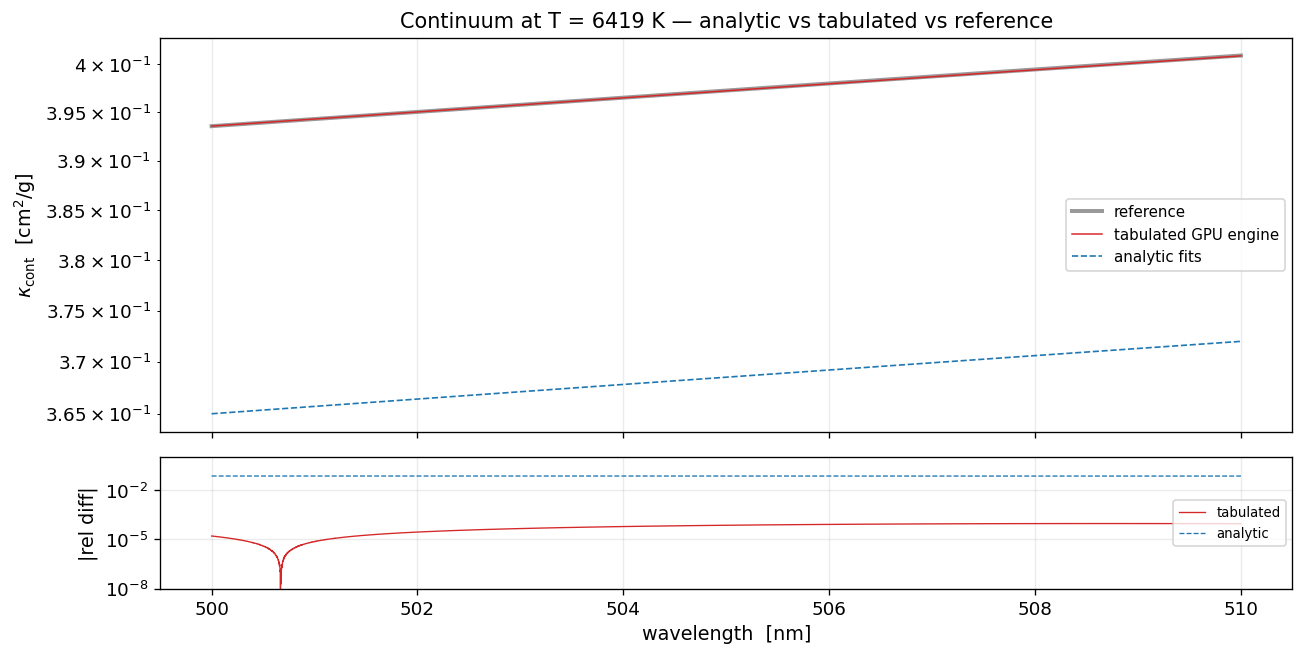

In [41]:
layer_p = int(np.argmin(np.abs(to_np(Tk) - 6400.0)))
analytic_total_np = to_np(kappa_Hminus + kappa_scat)
la3 = int(np.argmin(np.abs(REF["T"] - float(Tk[layer_p]))))
analytic_p = np.interp(to_np(wlk), REF["wl"], analytic_total_np[la3])

ref_tot_np = D_np["continuum_absorption"][layer_p] + D_np["continuum_scattering"][layer_p]  # numpy-ref
exact_tot_np = abs_gpu_np[layer_p] + sca_gpu_np[layer_p]

fig, (ax, axr) = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1]})
ax.plot(to_np(wlk), ref_tot_np, color="0.6", lw=2.4, label="reference")
ax.plot(to_np(wlk), exact_tot_np, color="C3", lw=0.9, label="tabulated GPU engine")
ax.plot(to_np(wlk), analytic_p, color="C0", lw=1.0, ls="--", label="analytic fits")
ax.set_yscale("log"); ax.set_ylabel(r"$\kappa_{\rm cont}$  [cm$^2$/g]")
ax.set_title(f"Continuum at T = {float(Tk[layer_p]):.0f} K — analytic vs tabulated vs reference")
ax.legend(loc="center right", fontsize=9)

rel_exact = np.abs(exact_tot_np - ref_tot_np) / np.maximum(np.abs(ref_tot_np), 1e-300)
rel_anal = np.abs(analytic_p - ref_tot_np) / np.maximum(np.abs(ref_tot_np), 1e-300)
axr.semilogy(to_np(wlk), np.maximum(rel_exact, 1e-18), color="C3", lw=0.8, label="tabulated")
axr.semilogy(to_np(wlk), np.maximum(rel_anal, 1e-18), color="C0", lw=0.8, ls="--", label="analytic")
axr.set_xlabel("wavelength  [nm]"); axr.set_ylabel("|rel diff|")
axr.set_ylim(1e-8 if DTYPE == torch.float32 else 1e-17, 1e0)
axr.legend(loc="center right", fontsize=8)
fig.tight_layout(); plt.show()

## Synthesis: what you built and where it goes

You turned the equation of state into a continuum opacity twice. First you built the physical model: the visible continuum of a cool star is carried mainly by H$^-$, whose abundance follows a Saha balance with the small detachment energy $\chi=0.754\ \mathrm{eV}$, and whose bound-free and free-free absorption can be represented by the John (1988) analytic fits. Rayleigh and Thomson scattering then add a small non-thermalizing floor.

Then you built the production-style engine. Each source was evaluated from its own table or fixed cross-section rule, sampled on the KAPP edge-triplet frequency grid, and reconstructed by the 3-point Lagrange interpolation. The GPU version emphasizes the array structure: populations are depth columns, frequency quantities are wavelength/frequency rows, and every physical source is a broadcast tensor over the whole depth--frequency plane. The diagnostic comparison is honest: the final opacity is the sum of the computed terms, and the reference appears only as the oracle.

This smooth continuum is the canvas. Lecture 4 paints a line opacity on top of it, adding a sharp, frequency-dependent profile whose core and wings are shaped by thermal, turbulent, natural, and collisional broadening.

## Summary

- Continuous extinction separates into **true absorption** and **scattering**; only absorption thermalizes photons and carries the stimulated-emission correction.
- In cool photospheres, **H$^-$** dominates the visible continuous absorption because its abundance scales with both neutral hydrogen and the electron density supplied by metals.
- The analytic John (1988) H$^-$ fits plus Rayleigh/Thomson scattering reproduce the reference at the few-percent physics level.
- The exact KAPP engine replaces those fits with tables: H$^-$ bound-free/free-free, H I Karzas--Latter bound-free, Coulomb free-free Gaunt factors, Gavrila Rayleigh scattering, helium continua, and minor molecular/metal absorbers.
- KAPP samples three frequencies per continuum edge interval and reconstructs $\log_{10}\kappa$ with a fixed 3-point Lagrange parabola.
- The GPU port keeps the computation vectorized over depth and sampled frequency; the only loops are over short fixed physics tables, never over layers or wavelengths.
- The benchmark reports the honest residual of the from-scratch GPU engine against the diagnostic reference; it is the parity gate for future improvements to the table-interpolation details.

## Practice exercises

**1. The H$^-$ threshold.** Plot the analytic H$^-$ bound-free cross-section from $0.2$ to $1.7\,\mu{\rm m}$. Where does it peak, and why must it vanish beyond $1.6419\,\mu{\rm m}$?

**2. Metal-poor continuum.** Reduce the electron density in the analytic H$^-$ calculation by a factor of ten. How does the continuum opacity shift, and which atmospheric layers would become visible?

**3. Source budget.** Zero all exact-engine source tensors except `budget_gpu["Hminus"]`, reconstruct the continuum, and compare to the full diagnostic. Where is the missing opacity largest?

**4. Interpolation test.** Replace the 3-point Lagrange reconstruction with a two-point linear interpolation in $\log_{10}\kappa$. How large is the resulting error across the 500--510 nm window?

**5. Precision audit.** Re-run this notebook on CPU/fp64 and on MPS/fp32. Which terms change the most, and does the worst point sit in the photosphere or in deep hot layers?

## Further reading

- **John, T. L. (1988), A&A, 193, 189.** Continuous absorption by H$^-$ and the analytic fits used for the pedagogical model.
- **Kurucz, R. L. (1970), SAO Special Report 309.** The original ATLAS continuous-opacity routines and tables.
- **Gavrila, M. (1967), Phys. Rev., 163, 147.** The Rayleigh-scattering polarizability factor for atomic hydrogen.
- **Karzas, W. J. & Latter, R. (1961), ApJS, 6, 167.** Hydrogenic bound-free and free-free Gaunt factors.
- **Wildt, R. (1939), ApJ, 90, 611.** The identification of H$^-$ as the key stellar photospheric opacity source.
- **Gray, D. F. (2005), *The Observation and Analysis of Stellar Photospheres*.** A clear textbook treatment of continuous opacity.
- **Kim, E. M. & Ting, Y.-S. (2026), *pykurucz*.** The Python implementation that generated the diagnostic reference used here.